# Bayesian Modeling of UTMB Finish Times — Final Report

This notebook is a cleaned, report-oriented version of the Bayesian workflow for modeling UTMB ultra-trail race finish times.

The goal is to model the **mean finish time** of a race using physical course characteristics. The response is modeled as

$$
\log(T_i), \qquad T_i = \text{Mean Finish Time in hours},
$$
because finish times are strictly positive and strongly right-skewed on the original hour scale.

Two models are compared:

- **Model 1:** Bayesian linear regression with a Normal likelihood on log-time.
- **Model 2:** Bayesian linear regression with a Student-t likelihood on log-time, designed to be more robust to heavy-tailed residuals and outlier races.

The notebook intentionally avoids reusing stale or inconsistent plots from the exploratory notebooks. All plots below are generated from the current preprocessing and model outputs.

## 0. Audit Notes and Reproducibility Decisions

The original project notebooks contained several pieces of useful work, but also a few inconsistencies. This final report follows these decisions:

1. The actual Stan files are treated as the source of truth for model specification.
2. Both models use the same four predictors:
   - standardized log-distance,
   - standardized log-elevation gain,
   - standardized log-steepness,
   - standardized log-altitude.
3. The intercept prior is the one implemented in Stan: $\alpha \sim \mathcal{N}(2.0, 1.0)$, not older markdown descriptions with $\alpha \sim \mathcal{N}(0,1)$.
4. Prior predictive checks are simulated directly in Python from the same priors. This avoids unreliable fixed-parameter Stan outputs observed in the older notebook.
5. EDA is performed on the full cleaned dataset. Posterior sampling is performed on a reproducible subsample to keep generated quantities and model comparison computationally manageable.
6. WAIC and PSIS-LOO are computed from the `log_lik` variables generated by Stan on the log-time scale.

## 1. Setup

The notebook requires `pandas`, `numpy`, `scipy`, `matplotlib`, `arviz`, and `cmdstanpy`. The raw dataset can be loaded either from a local CSV file or through `kagglehub` if available.

In [41]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az

warnings.filterwarnings("ignore")

# Optional imports are handled later when needed.

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Sampling and plotting configuration.
MODEL_SAMPLE_N = 5_000          # posterior fitting subset size
PRIOR_DRAWS = 800               # prior predictive draws
PRIOR_PPC_N = 5_000             # observations used in prior predictive plots
POSTERIOR_PPC_DRAWS = 200       # posterior predictive draws shown in plots
SCATTER_N = 8_000               # maximum points shown in dense scatterplots

CHAINS = 4
ITER_WARMUP = 1_000
ITER_SAMPLING = 1_000
ADAPT_DELTA = 0.90
MAX_TREEDEPTH = 12

ROOT = Path.cwd()
FIG_DIR = ROOT / "report_figures"
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

az.style.use("arviz-whitegrid")

print(f"Working directory: {ROOT}")
print(f"Figures will be saved to: {FIG_DIR}")

Working directory: /workspace/utmb_project/utmb_race_finish_times_bayesian_analysis
Figures will be saved to: /workspace/utmb_project/utmb_race_finish_times_bayesian_analysis/report_figures


## 2. Data Loading and Preprocessing

The dataset used in the project is the UTMB World Race Data dataset. The relevant columns are race category, distance, elevation gain, mean finish time, winning time, participation statistics, year, country, and altitude/elevation above sea level.

The preprocessing follows the same modeling logic for both models:

- keep main UTMB categories: `20K`, `50K`, `100K`, `100M`,
- remove missing or physically impossible values,
- remove extreme likely data-entry errors,
- model `log(Mean Finish Time)`,
- log-transform distance and elevation-related predictors,
- standardize predictors to mean 0 and standard deviation 1.

In [42]:
def find_dataset_csv() -> Path:
    '''Find the UTMB CSV file locally or download it through kagglehub if available.'''
    candidates = [
        ROOT / "utmb-race-data-sheet.csv",
        ROOT / "utmb_processed.csv",  # fallback: already-cleaned file from previous notebooks
        Path.home() / ".cache/kagglehub/datasets/mgpoirot/utmb-world-race-daa/versions/1/utmb-race-data-sheet.csv",
    ]
    for path in candidates:
        if path.exists():
            return path

    try:
        import kagglehub
        data_path = Path(kagglehub.dataset_download("mgpoirot/utmb-world-race-daa"))
        csv_path = data_path / "utmb-race-data-sheet.csv"
        if csv_path.exists():
            return csv_path
    except Exception as exc:
        raise FileNotFoundError(
            "Could not find the UTMB CSV locally and kagglehub download failed. "
            "Place 'utmb-race-data-sheet.csv' or 'utmb_processed.csv' in the notebook directory."
        ) from exc

    raise FileNotFoundError("Could not locate the UTMB dataset CSV file.")


def standardize(series: pd.Series) -> pd.Series:
    std = series.std(ddof=1)
    if std == 0 or np.isnan(std):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std


def preprocess_raw_data(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    '''Clean the raw UTMB dataset and create final model variables.'''
    required = [
        "Race Category", "Distance", "Elevation Gain", "Mean Finish Time",
        "Winning Time", "N Participants", "Year", "Country"
    ]
    optional = ["Elevation"]
    present = [c for c in required + optional if c in df_raw.columns]
    df = df_raw[present].copy()

    # If an already processed file is loaded, it may not contain all raw columns.
    if "Elevation" not in df.columns:
        df["Elevation"] = 0.0

    missing_before = df.isna().sum().rename("missing_count").to_frame()
    missing_before["missing_fraction"] = missing_before["missing_count"] / len(df)

    main_categories = ["20K", "50K", "100K", "100M"]
    df = df[df["Race Category"].isin(main_categories)].copy()

    # Required numeric fields.
    df = df.dropna(subset=["Mean Finish Time", "Winning Time", "Distance", "Elevation Gain"])

    # Physical and consistency filters.
    df = df[(df["Mean Finish Time"] > 0) & (df["Winning Time"] > 0)]
    df = df[df["Winning Time"] <= df["Mean Finish Time"]]
    df = df[(df["Distance"] > 5) & (df["Distance"] < 300)]
    df = df[(df["Elevation Gain"] >= 100) & (df["Elevation Gain"] < 20_000)]
    df = df[(df["Mean Finish Time"] < 80) & (df["Winning Time"] < 50)]

    # Feature engineering.
    df["elevation_per_km"] = df["Elevation Gain"] / df["Distance"]
    df["log_time"] = np.log(df["Mean Finish Time"])
    df["log_distance"] = np.log(df["Distance"])
    df["log_elevation_gain"] = np.log1p(df["Elevation Gain"])
    df["log_steepness"] = np.log1p(df["elevation_per_km"])
    df["log_altitude"] = np.log1p(df["Elevation"].clip(lower=0))

    # Model variables.
    df["distance_log_std"] = standardize(df["log_distance"])
    df["elevation_log_std"] = standardize(df["log_elevation_gain"])
    df["steepness_std"] = standardize(df["log_steepness"])
    df["altitude_std"] = standardize(df["log_altitude"])

    return df.reset_index(drop=True), missing_before


csv_path = find_dataset_csv()
print(f"Dataset path: {csv_path}")

df_raw = pd.read_csv(csv_path, low_memory=False)
df, missing_before = preprocess_raw_data(df_raw)

print(f"Raw dataset shape:     {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
print(f"Cleaned dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nRace category counts after cleaning:")
print(df["Race Category"].value_counts().to_string())

model_vars = ["log_time", "distance_log_std", "elevation_log_std", "steepness_std", "altitude_std"]
print("\nFinal model variables:")
print(df[model_vars].agg(["mean", "std", "min", "max"]).T.round(3))

Dataset path: /workspace/utmb_project/utmb_race_finish_times_bayesian_analysis/utmb_processed.csv
Raw dataset shape:     36,433 rows x 24 columns
Cleaned dataset shape: 36,401 rows x 19 columns

Race category counts after cleaning:
Race Category
50K     15480
20K     10742
100K     7389
100M     2790

Final model variables:
                    mean    std    min    max
log_time           2.096  0.723 -0.136  4.340
distance_log_std   0.000  1.000 -3.389  2.885
elevation_log_std -0.000  1.000 -4.107  3.012
steepness_std      0.000  1.000 -6.384  4.009
altitude_std      -0.000  1.000 -3.524  2.056


### 2.1 Missing Values

The missing value summary is computed before filtering. This makes it clear which fields required cleaning and whether missingness was substantial enough to require a dedicated imputation strategy.

## 3. Exploratory Data Analysis

This section focuses on the variables used by the models. The response is inspected on both the original hour scale and the log scale. The predictors are inspected both before and after transformations.

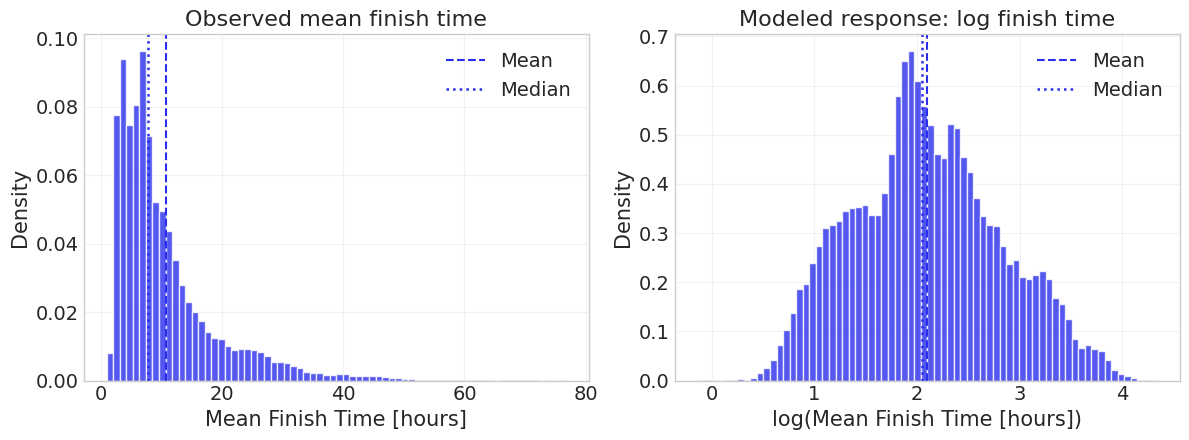

,Mean Finish Time [h],log_time
count,36401.000,36401.000
mean,10.628,2.096
std,8.641,0.723
min,0.873,-0.136
25%,4.825,1.574
50%,7.785,2.052
75%,13.129,2.575
max,76.729,4.340


In [43]:
def sample_for_plot(data: pd.DataFrame, n: int = SCATTER_N) -> pd.DataFrame:
    if len(data) <= n:
        return data
    return data.sample(n=n, random_state=RANDOM_SEED)


def plot_response_distributions(data: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].hist(data["Mean Finish Time"], bins=70, density=True, alpha=0.8, edgecolor="white")
    axes[0].axvline(data["Mean Finish Time"].mean(), linestyle="--", linewidth=1.5, label="Mean")
    axes[0].axvline(data["Mean Finish Time"].median(), linestyle=":", linewidth=1.8, label="Median")
    axes[0].set_title("Observed mean finish time")
    axes[0].set_xlabel("Mean Finish Time [hours]")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    axes[1].hist(data["log_time"], bins=70, density=True, alpha=0.8, edgecolor="white")
    axes[1].axvline(data["log_time"].mean(), linestyle="--", linewidth=1.5, label="Mean")
    axes[1].axvline(data["log_time"].median(), linestyle=":", linewidth=1.8, label="Median")
    axes[1].set_title("Modeled response: log finish time")
    axes[1].set_xlabel("log(Mean Finish Time [hours])")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "response_distributions.png", bbox_inches="tight")
    plt.show()

    stats_table = pd.DataFrame({
        "Mean Finish Time [h]": data["Mean Finish Time"].describe(),
        "log_time": data["log_time"].describe(),
    })
    display(stats_table.round(3))

plot_response_distributions(df)

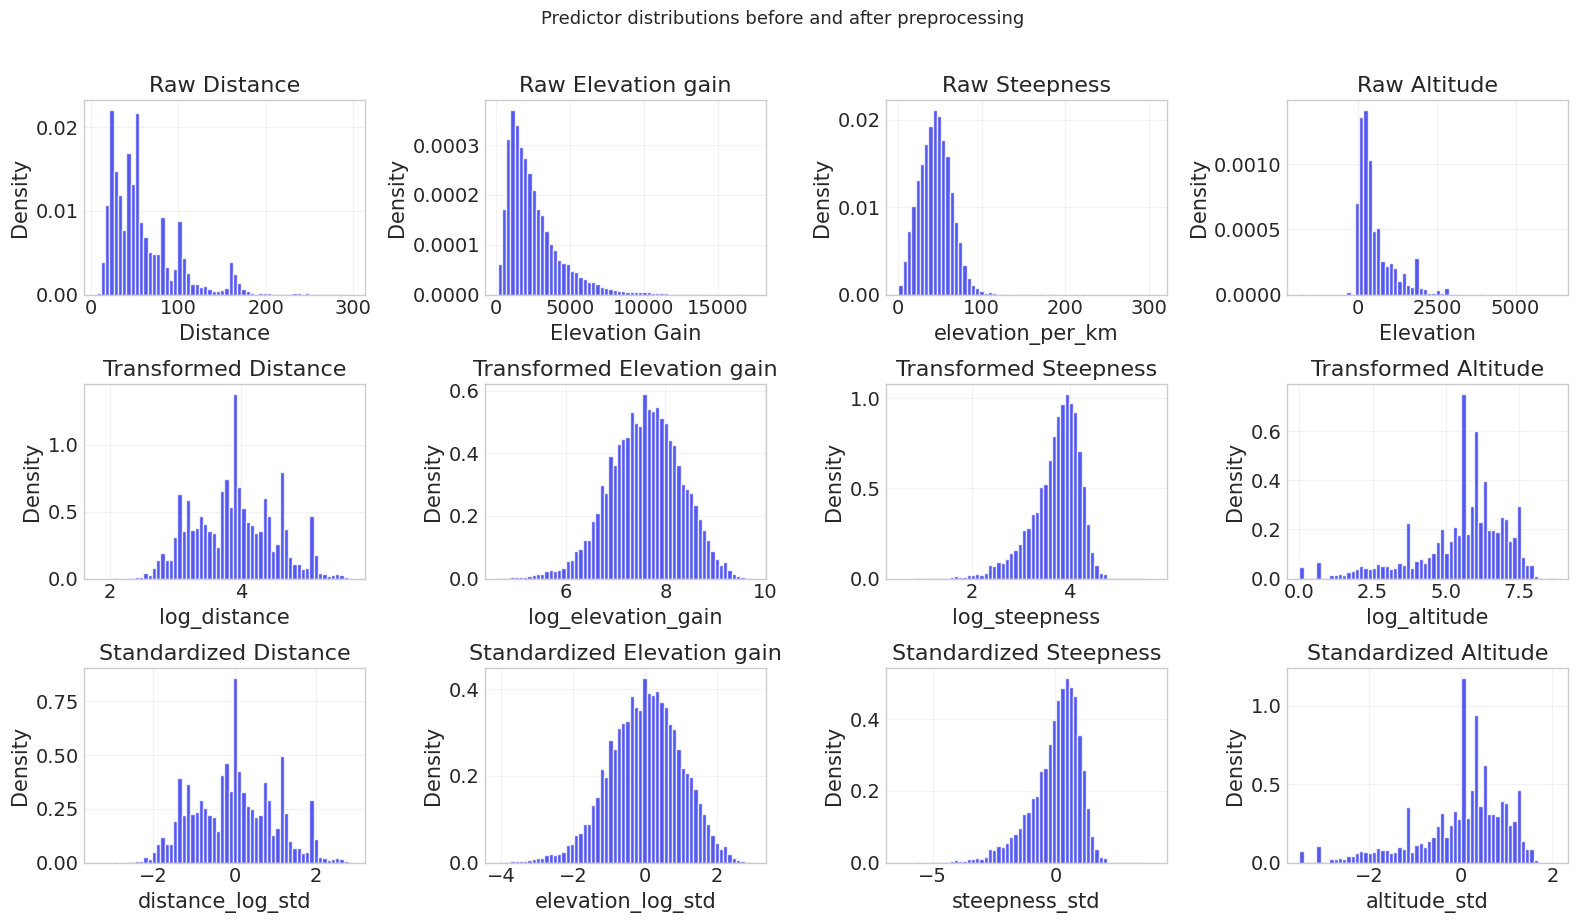

In [44]:
def plot_predictor_distributions(data: pd.DataFrame):
    raw_cols = ["Distance", "Elevation Gain", "elevation_per_km", "Elevation"]
    transformed_cols = ["log_distance", "log_elevation_gain", "log_steepness", "log_altitude"]
    std_cols = ["distance_log_std", "elevation_log_std", "steepness_std", "altitude_std"]
    titles = ["Distance", "Elevation gain", "Steepness", "Altitude"]

    fig, axes = plt.subplots(3, 4, figsize=(16, 9))
    for j, (raw, trans, std, title) in enumerate(zip(raw_cols, transformed_cols, std_cols, titles)):
        axes[0, j].hist(data[raw], bins=60, density=True, alpha=0.8, edgecolor="white")
        axes[0, j].set_title(f"Raw {title}")
        axes[0, j].set_xlabel(raw)

        axes[1, j].hist(data[trans], bins=60, density=True, alpha=0.8, edgecolor="white")
        axes[1, j].set_title(f"Transformed {title}")
        axes[1, j].set_xlabel(trans)

        axes[2, j].hist(data[std], bins=60, density=True, alpha=0.8, edgecolor="white")
        axes[2, j].set_title(f"Standardized {title}")
        axes[2, j].set_xlabel(std)

    for ax in axes.flat:
        ax.set_ylabel("Density")
    plt.suptitle("Predictor distributions before and after preprocessing", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "predictor_preprocessing.png", bbox_inches="tight")
    plt.show()

plot_predictor_distributions(df)

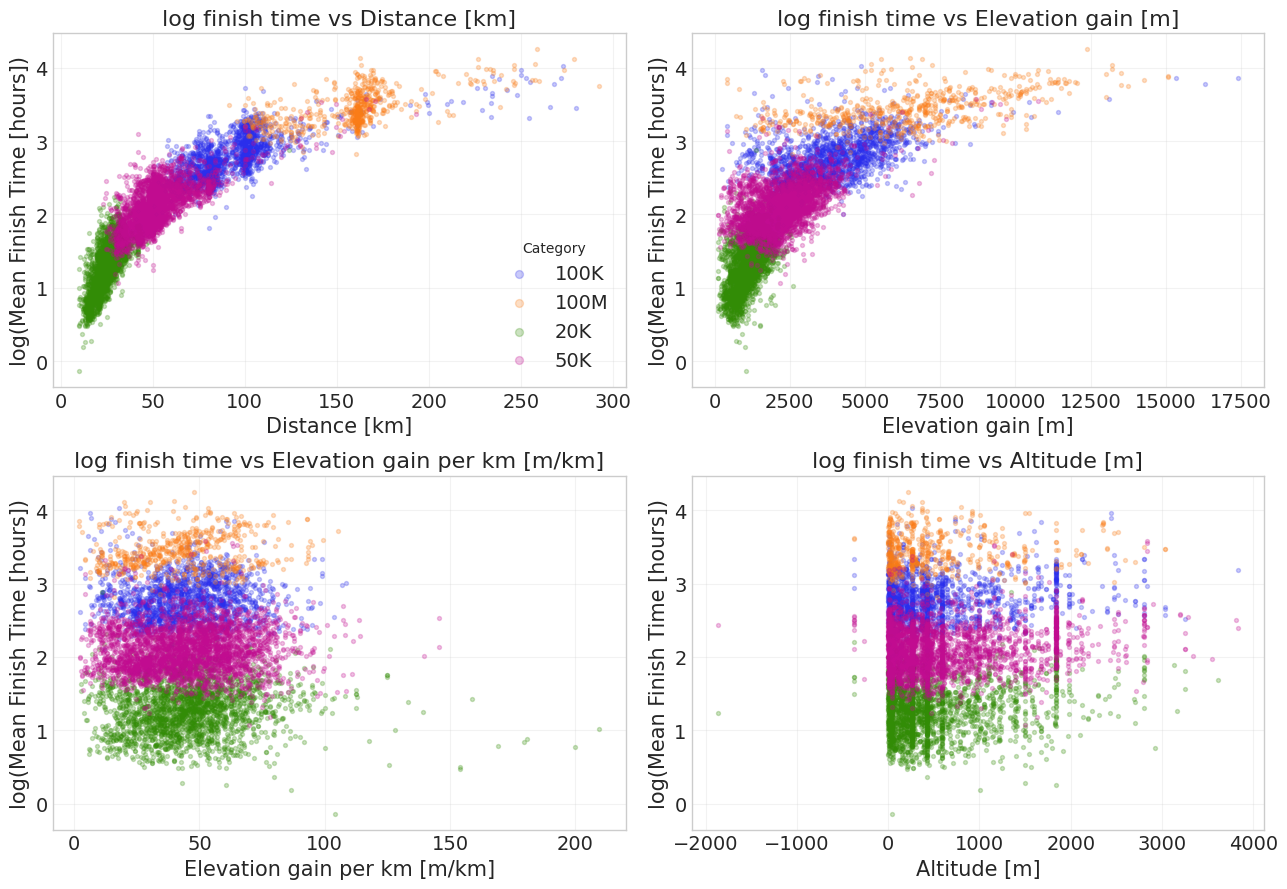

In [45]:
def plot_response_vs_predictors(data: pd.DataFrame):
    plot_df = sample_for_plot(data)
    predictors = [
        ("Distance", "Distance [km]"),
        ("Elevation Gain", "Elevation gain [m]"),
        ("elevation_per_km", "Elevation gain per km [m/km]"),
        ("Elevation", "Altitude [m]")
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, (col, label) in zip(axes.flat, predictors):
        for cat, sub in plot_df.groupby("Race Category"):
            ax.scatter(sub[col], sub["log_time"], s=8, alpha=0.25, label=cat)
        ax.set_xlabel(label)
        ax.set_ylabel("log(Mean Finish Time [hours])")
        ax.set_title(f"log finish time vs {label}")
    axes[0, 0].legend(title="Category", markerscale=2)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "scatter_response_vs_predictors.png", bbox_inches="tight")
    plt.show()

plot_response_vs_predictors(df)

## 4. Problem Formulation and Model Variables

The modeling target is the conditional distribution of log finish time:

$$
y_i = \log(T_i),
$$
where $T_i$ is the mean finish time in hours for race $i$.

The linear predictor is shared by both models:

$$
\mu_i = \alpha
+ \beta_{dist} x_{dist,i}
+ \beta_{elev} x_{elev,i}
+ \beta_{steep} x_{steep,i}
+ \beta_{alt} x_{alt,i}.
$$
The four predictors represent distance, total elevation gain, route steepness, and altitude. All are standardized, so coefficients are interpretable as approximate multiplicative effects per one standard deviation increase after exponentiation.

In [46]:
variable_table = pd.DataFrame({
    "Variable": [
        "log_time", "distance_log_std", "elevation_log_std", "steepness_std", "altitude_std"
    ],
    "Definition": [
        "log(Mean Finish Time in hours)",
        "standardized log(Distance)",
        "standardized log(1 + Elevation Gain)",
        "standardized log(1 + Elevation Gain / Distance)",
        "standardized log(1 + altitude above sea level)"
    ],
    "Role": ["response", "predictor", "predictor", "predictor", "predictor"]
})

display(variable_table)

,Variable,Definition,Role
0,log_time,log(Mean Finish Time in hours),response
1,distance_log_std,standardized log(Distance),predictor
2,elevation_log_std,standardized log(1 + Elevation Gain),predictor
3,steepness_std,standardized log(1 + Elevation Gain / Distance),predictor
4,altitude_std,standardized log(1 + altitude above sea level),predictor


## 5. Model Specification

### Model 1: Normal likelihood

$$
y_i \sim \mathcal{N}(\mu_i, \sigma),
$$
with the shared linear predictor defined above.

### Model 2: Student-t likelihood

$$
y_i \sim t_\nu(\mu_i, \sigma),
$$
where $\nu > 2$ controls tail heaviness. Smaller values of $\nu$ imply heavier tails. This allows atypically slow or otherwise unusual races to be represented without forcing the residual standard deviation $\sigma$ to inflate for all observations.

In [47]:
MODEL1_STAN = ROOT / "model1_normal.stan"
MODEL2_STAN = ROOT / "model2_student_t.stan"

for path in [MODEL1_STAN, MODEL2_STAN]:
    if not path.exists():
        raise FileNotFoundError(f"Required Stan file not found: {path}")
    print(f"Found Stan file: {path.name}")

print("\nModel 1 Stan header:")
print("\n".join(MODEL1_STAN.read_text().splitlines()[:22]))

Found Stan file: model1_normal.stan
Found Stan file: model2_student_t.stan

Model 1 Stan header:
// Model 1: Normal Linear Regression on LOG finish time
//
// log(T_i) ~ Normal(mu_i, sigma)
// mu_i = alpha
//        + beta_dist  * distance_log_std
//        + beta_elev  * elevation_log_std
//        + beta_steep * steepness_std
//        + beta_alt   * altitude_std
//
// All four predictors are standardized (mean 0, sd 1).
// Modelling log(T) guarantees time_rep = exp(log_time_rep) > 0.
//
// Prior rationale
// ---------------
// alpha  : Normal(0, 1)  — weakly informative intercept; NOT centred on the
//          sample mean. On the log-hour scale exp(-2,+2) = [0.14, 7.4] h,
//          intentionally vague so the data dominate.
//
// beta_dist : Normal(0.7, 0.4)  — Riegel's power-law (Riegel 1981) gives
//             time ∝ dist^1.06, so the log-log elasticity is ~1.06.
//             With SD(log dist) ≈ 0.6-0.8 in this dataset, the coefficient
//             on *standardised* log-di

## 6. Priors and Prior Predictive Checks

The priors below match the uploaded Stan files. Since all predictors are standardized, the slope priors are defined on a comparable one-standard-deviation scale.

$$
\begin{aligned}
\alpha &\sim \mathcal{N}(2.0, 1.0),\\
\beta_{dist} &\sim \mathcal{N}(0.7, 0.4),\\
\beta_{elev} &\sim \mathcal{N}(0.2, 0.3),\\
\beta_{steep} &\sim \mathcal{N}(0.15, 0.2),\\
\beta_{alt} &\sim \mathcal{N}(0.05, 0.1),\\
\sigma &\sim \text{HalfNormal}(0, 0.3),\\
\nu &= 2 + \nu_{-2}, \qquad \nu_{-2} \sim \text{Gamma}(2, 0.1) \quad \text{for Model 2 only.}
\end{aligned}
$$
Prior predictive simulation is performed directly in Python. This is deliberate: old fixed-parameter Stan prior-predictive outputs contained unreliable zero-valued scalar draws.

In [48]:
def simulate_priors(n_draws: int, rng: np.random.Generator) -> pd.DataFrame:
    return pd.DataFrame({
        "alpha": rng.normal(2.0, 1.0, n_draws),
        "beta_dist": rng.normal(0.7, 0.4, n_draws),
        "beta_elev": rng.normal(0.2, 0.3, n_draws),
        "beta_steep": rng.normal(0.15, 0.2, n_draws),
        "beta_alt": rng.normal(0.05, 0.1, n_draws),
        "sigma": np.abs(rng.normal(0, 0.3, n_draws)),
        "nu": 2 + rng.gamma(shape=2, scale=1/0.1, size=n_draws),
    })

prior_draws = simulate_priors(PRIOR_DRAWS, rng)
display(prior_draws.describe(percentiles=[0.025, 0.5, 0.975]).T.round(3))

,count,mean,std,min,2.5%,50%,97.5%,max
alpha,800.0,1.971,0.984,-0.965,0.009,1.991,3.878,4.914
beta_dist,800.0,0.684,0.408,-0.759,-0.147,0.697,1.462,1.972
beta_elev,800.0,0.183,0.302,-0.719,-0.417,0.203,0.781,1.074
beta_steep,800.0,0.158,0.200,-0.422,-0.222,0.152,0.553,0.762
beta_alt,800.0,0.049,0.098,-0.225,-0.137,0.046,0.244,0.359
sigma,800.0,0.235,0.187,0.000,0.009,0.193,0.714,1.036
nu,800.0,22.584,13.841,2.778,4.699,19.480,59.447,83.863


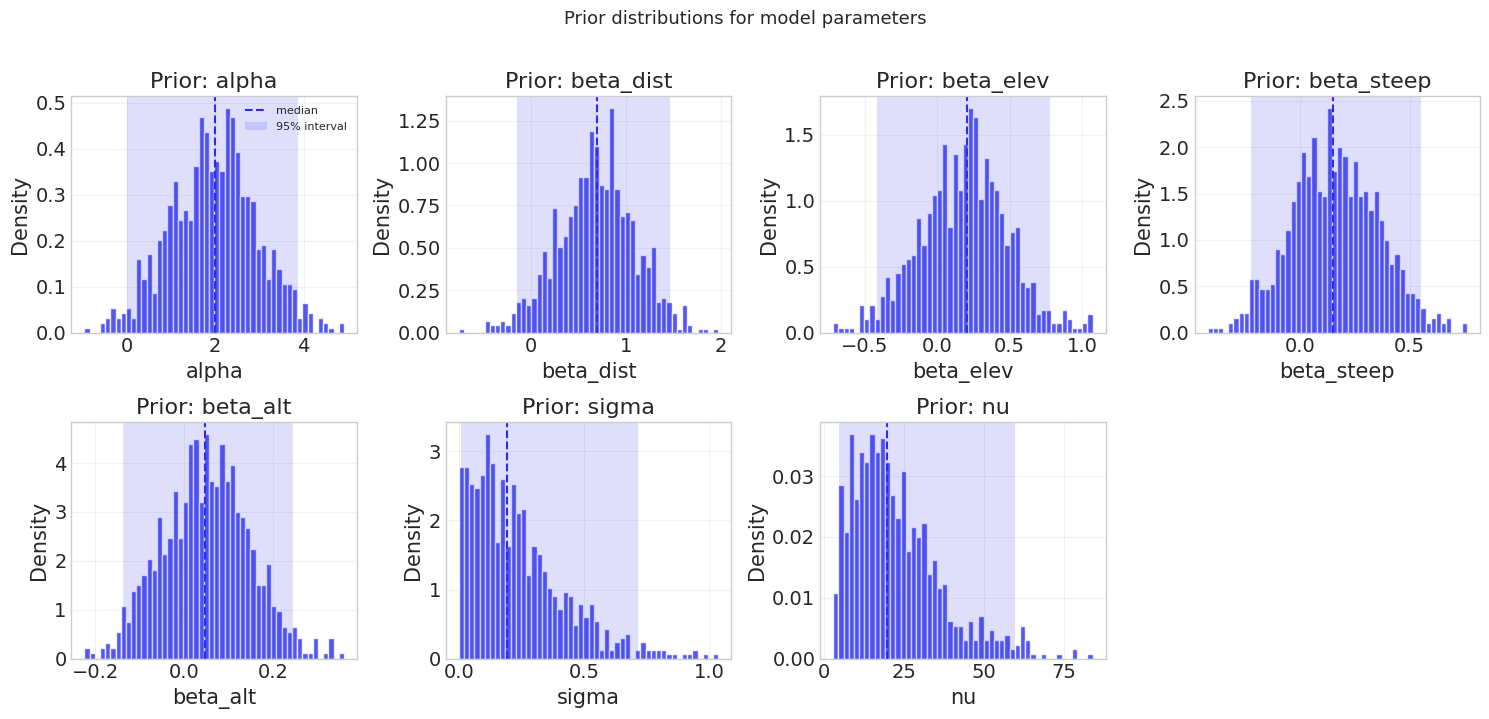

In [49]:
def plot_prior_distributions(prior: pd.DataFrame):
    params = ["alpha", "beta_dist", "beta_elev", "beta_steep", "beta_alt", "sigma", "nu"]
    fig, axes = plt.subplots(2, 4, figsize=(15, 7))
    axes = axes.ravel()

    for ax, param in zip(axes, params):
        ax.hist(prior[param], bins=50, density=True, alpha=0.8, edgecolor="white")
        lo, med, hi = np.percentile(prior[param], [2.5, 50, 97.5])
        ax.axvline(med, linestyle="--", linewidth=1.5, label="median")
        ax.axvspan(lo, hi, alpha=0.15, label="95% interval")
        ax.set_title(f"Prior: {param}")
        ax.set_xlabel(param)
        ax.set_ylabel("Density")
    axes[-1].axis("off")
    axes[0].legend(fontsize=8)
    plt.suptitle("Prior distributions for model parameters", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "prior_distributions.png", bbox_inches="tight")
    plt.show()

plot_prior_distributions(prior_draws)

In [50]:
def prior_predictive_simulation(data: pd.DataFrame, prior: pd.DataFrame, likelihood: str = "student_t"):
    '''Return log-time and hour-scale prior predictive simulations.'''
    ppc_df = data.sample(n=min(PRIOR_PPC_N, len(data)), random_state=RANDOM_SEED).reset_index(drop=True)
    X = ppc_df[["distance_log_std", "elevation_log_std", "steepness_std", "altitude_std"]].to_numpy()
    coefs = prior[["beta_dist", "beta_elev", "beta_steep", "beta_alt"]].to_numpy()
    mu = prior["alpha"].to_numpy()[:, None] + coefs @ X.T

    if likelihood == "normal":
        log_rep = rng.normal(mu, prior["sigma"].to_numpy()[:, None])
    elif likelihood == "student_t":
        eps = stats.t.rvs(df=prior["nu"].to_numpy()[:, None], size=mu.shape, random_state=rng)
        log_rep = mu + prior["sigma"].to_numpy()[:, None] * eps
    else:
        raise ValueError("likelihood must be 'normal' or 'student_t'")

    # Avoid numerical overflow in visualization; values above exp(8) ~ 2980 h are already implausible.
    time_rep = np.exp(np.clip(log_rep, -5, 8))
    return ppc_df, log_rep, time_rep

ppc_df, prior_log_rep_t, prior_time_rep_t = prior_predictive_simulation(df, prior_draws, likelihood="student_t")
_, prior_log_rep_n, prior_time_rep_n = prior_predictive_simulation(df, prior_draws, likelihood="normal")

print(f"Prior predictive array shape: {prior_time_rep_t.shape}")

Prior predictive array shape: (800, 5000)


In [51]:
def _hist_density_envelope(samples_2d: np.ndarray, bins: np.ndarray):
    """
    Compute density histogram envelope across simulation draws.

    samples_2d shape: (n_draws, n_observations)
    """
    densities = []
    for row in samples_2d:
        density, _ = np.histogram(row, bins=bins, density=True)
        densities.append(density)

    densities = np.asarray(densities)
    centers = 0.5 * (bins[:-1] + bins[1:])

    return pd.DataFrame({
        "x": centers,
        "q05": np.quantile(densities, 0.05, axis=0),
        "q25": np.quantile(densities, 0.25, axis=0),
        "q50": np.quantile(densities, 0.50, axis=0),
        "q75": np.quantile(densities, 0.75, axis=0),
        "q95": np.quantile(densities, 0.95, axis=0),
    })


def _ecdf_envelope(samples_2d: np.ndarray, x_grid: np.ndarray):
    """
    Compute ECDF envelope across simulation draws.
    """
    ecdfs = []
    for row in samples_2d:
        row = np.asarray(row)
        ecdfs.append([(row <= x).mean() for x in x_grid])

    ecdfs = np.asarray(ecdfs)

    return pd.DataFrame({
        "x": x_grid,
        "q05": np.quantile(ecdfs, 0.05, axis=0),
        "q25": np.quantile(ecdfs, 0.25, axis=0),
        "q50": np.quantile(ecdfs, 0.50, axis=0),
        "q75": np.quantile(ecdfs, 0.75, axis=0),
        "q95": np.quantile(ecdfs, 0.95, axis=0),
    })


def plot_prior_predictive_better(
    ppc_df: pd.DataFrame,
    log_rep: np.ndarray,
    time_rep: np.ndarray,
    label: str,
):
    """
    Cleaner prior predictive check:
    1. Density envelope on log scale.
    2. ECDF envelope on original hour scale.

    This avoids unreadable overlays of many transparent histograms.
    """

    # Use a limited number of prior draws for visualization only
    n_draws = min(500, log_rep.shape[0])
    log_rep_vis = log_rep[:n_draws]
    time_rep_vis = time_rep[:n_draws]

    observed_log = ppc_df["log_time"].to_numpy()
    observed_time = ppc_df["Mean Finish Time"].to_numpy()

    # -----------------------------
    # 1. Log-scale density envelope
    # -----------------------------
    lower = min(np.quantile(observed_log, 0.001), np.quantile(log_rep_vis, 0.01))
    upper = max(np.quantile(observed_log, 0.999), np.quantile(log_rep_vis, 0.99))

    # Avoid a visually useless range caused by extreme prior draws
    lower = max(lower, observed_log.min() - 2.0)
    upper = min(upper, observed_log.max() + 2.5)

    log_bins = np.linspace(lower, upper, 70)
    log_env = _hist_density_envelope(log_rep_vis, log_bins)

    obs_log_density, _ = np.histogram(observed_log, bins=log_bins, density=True)
    log_centers = 0.5 * (log_bins[:-1] + log_bins[1:])

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.fill_between(
        log_env["x"],
        log_env["q05"],
        log_env["q95"],
        alpha=0.20,
        label="Prior predictive 90% envelope",
    )
    ax.fill_between(
        log_env["x"],
        log_env["q25"],
        log_env["q75"],
        alpha=0.30,
        label="Prior predictive 50% envelope",
    )
    ax.plot(
        log_env["x"],
        log_env["q50"],
        linewidth=2,
        label="Prior predictive median density",
    )
    ax.step(
        log_centers,
        obs_log_density,
        where="mid",
        linewidth=2,
        label="Observed density",
    )

    ax.set_title(f"Prior predictive check on log scale — {label}")
    ax.set_xlabel("log(Mean Finish Time [hours])")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / f"prior_predictive_log_scale_{label.lower().replace(' ', '_')}.png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()

    # -----------------------------
    # 2. Hour-scale ECDF envelope
    # -----------------------------
    # ECDF is much more readable than histograms for skewed finish times.
    x_max = np.quantile(observed_time, 0.995)
    x_max = max(x_max, 40)
    x_grid = np.linspace(0, x_max, 250)

    ecdf_env = _ecdf_envelope(time_rep_vis, x_grid)
    obs_sorted = np.sort(observed_time)
    obs_ecdf = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.fill_between(
        ecdf_env["x"],
        ecdf_env["q05"],
        ecdf_env["q95"],
        alpha=0.20,
        label="Prior predictive 90% envelope",
    )
    ax.fill_between(
        ecdf_env["x"],
        ecdf_env["q25"],
        ecdf_env["q75"],
        alpha=0.30,
        label="Prior predictive 50% envelope",
    )
    ax.plot(
        ecdf_env["x"],
        ecdf_env["q50"],
        linewidth=2,
        label="Prior predictive median ECDF",
    )
    ax.step(
        obs_sorted,
        obs_ecdf,
        where="post",
        linewidth=2,
        label="Observed ECDF",
    )

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1.01)
    ax.set_title(f"Prior predictive check on hour scale — {label}")
    ax.set_xlabel("Mean Finish Time [hours]")
    ax.set_ylabel("Cumulative probability")
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / f"prior_predictive_hour_scale_ecdf_{label.lower().replace(' ', '_')}.png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()
    


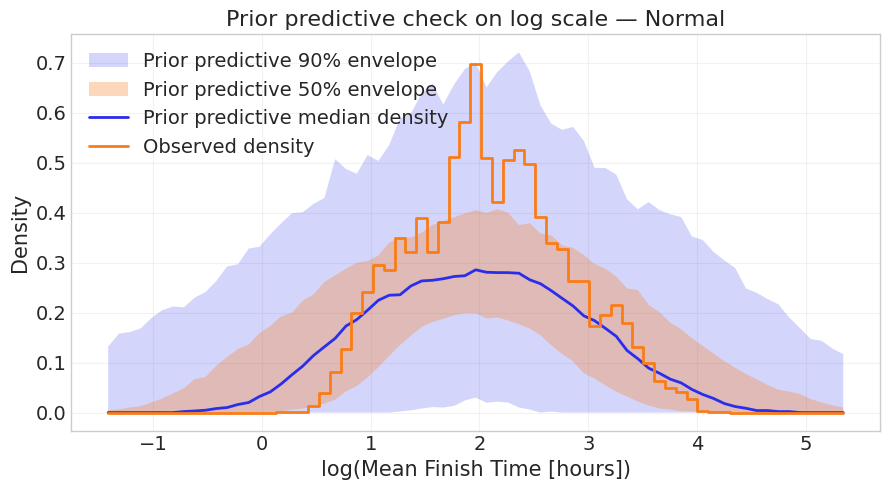

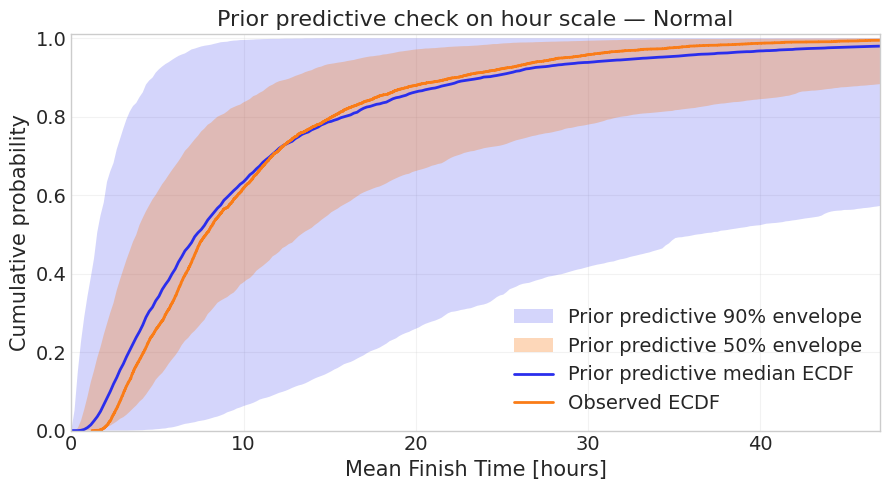

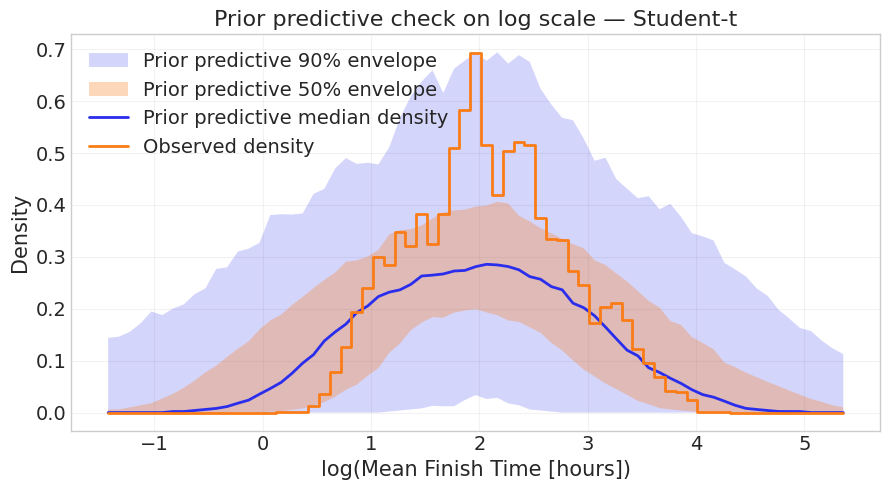

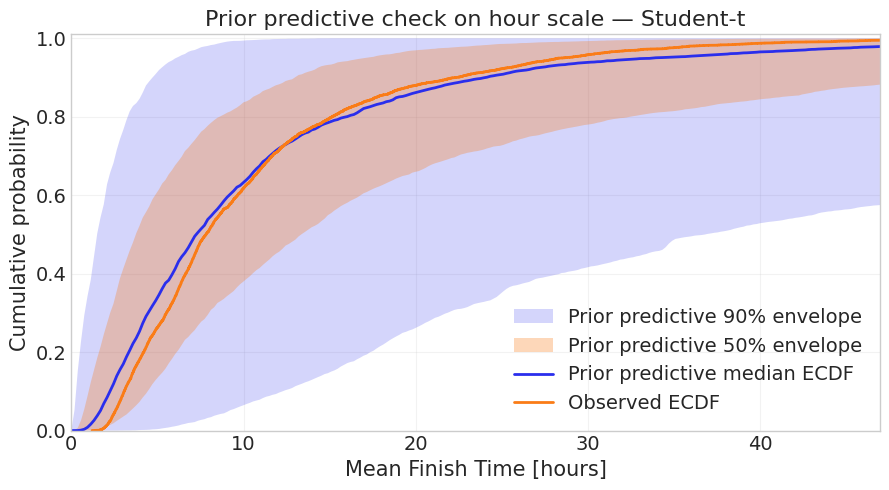

In [52]:
plot_prior_predictive_better(ppc_df, prior_log_rep_n, prior_time_rep_n, "Normal")
plot_prior_predictive_better(ppc_df, prior_log_rep_t, prior_time_rep_t, "Student-t")

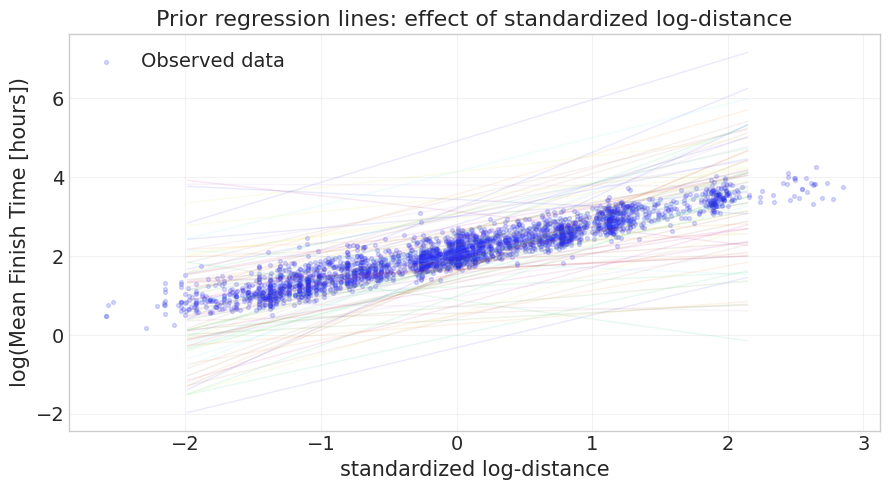

In [53]:
def plot_prior_regression_lines(data: pd.DataFrame, prior: pd.DataFrame):
    plot_df = sample_for_plot(data, n=3000)
    x_grid = np.linspace(data["distance_log_std"].quantile(0.01), data["distance_log_std"].quantile(0.99), 120)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(plot_df["distance_log_std"], plot_df["log_time"], s=8, alpha=0.18, label="Observed data")

    draws = prior.sample(n=min(80, len(prior)), random_state=RANDOM_SEED)
    for _, row in draws.iterrows():
        # Hold other standardized predictors at 0: an average course profile.
        mu = row["alpha"] + row["beta_dist"] * x_grid
        ax.plot(x_grid, mu, alpha=0.10, linewidth=1)

    ax.set_title("Prior regression lines: effect of standardized log-distance")
    ax.set_xlabel("standardized log-distance")
    ax.set_ylabel("log(Mean Finish Time [hours])")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "prior_regression_lines.png", bbox_inches="tight")
    plt.show()

plot_prior_regression_lines(df, prior_draws)

## 7. Posterior Sampling

The EDA uses the full cleaned dataset. To keep the Stan generated quantities, posterior predictive arrays, and pointwise log-likelihood matrices manageable, the models are fitted to a reproducible subsample.

Both models receive exactly the same rows and exactly the same predictors.

In [54]:
def make_modeling_subset(data: pd.DataFrame, n: int = MODEL_SAMPLE_N) -> pd.DataFrame:
    if len(data) <= n:
        return data.copy().reset_index(drop=True)
    return data.sample(n=n, random_state=RANDOM_SEED).reset_index(drop=True)

model_df = make_modeling_subset(df)

stan_data = {
    "N": int(len(model_df)),
    "log_time": model_df["log_time"].to_numpy(),
    "distance_log_std": model_df["distance_log_std"].to_numpy(),
    "elevation_log_std": model_df["elevation_log_std"].to_numpy(),
    "steepness_std": model_df["steepness_std"].to_numpy(),
    "altitude_std": model_df["altitude_std"].to_numpy(),
}

print(f"Modeling subset: {len(model_df):,} observations")
print(model_df[["Mean Finish Time", "log_time", "Distance", "Elevation Gain", "elevation_per_km", "Elevation"]].describe().round(3))

Modeling subset: 5,000 observations
       Mean Finish Time  log_time  Distance  Elevation Gain  elevation_per_km  \
count          5000.000  5000.000  5000.000        5000.000          5000.000   
mean             10.579     2.094    59.882        2534.811            45.001   
std               8.513     0.722    40.317        1905.036            19.567   
min               1.205     0.187     9.900         120.000             1.887   
25%               4.816     1.572    30.075        1210.000            31.056   
50%               7.823     2.057    50.000        2000.000            44.444   
75%              13.055     2.569    78.825        3270.000            57.345   
max              70.132     4.250   292.800       17402.000           200.000   

       Elevation  
count   5000.000  
mean     542.781  
std      597.375  
min    -1870.100  
25%      129.370  
50%      336.335  
75%      730.872  
max     3835.530  


In [55]:
from cmdstanpy import CmdStanModel

RUN_SAMPLING = True
LOAD_EXISTING_IDATA = True

IDATA1_PATH = ROOT / "idata_model1_normal.nc"
IDATA2_PATH = ROOT / "idata_model2_student_t.nc"
TIME_MU1_PATH = ROOT / "time_mu_model1.npy"
TIME_MU2_PATH = ROOT / "time_mu_model2.npy"
TIME_REP1_PATH = ROOT / "time_rep_model1.npy"
TIME_REP2_PATH = ROOT / "time_rep_model2.npy"


def fit_stan_model(stan_file: Path, data: dict, seed: int):
    model = CmdStanModel(stan_file=str(stan_file))
    fit = model.sample(
        data=data,
        chains=CHAINS,
        iter_warmup=ITER_WARMUP,
        iter_sampling=ITER_SAMPLING,
        seed=seed,
        adapt_delta=ADAPT_DELTA,
        max_treedepth=MAX_TREEDEPTH,
        show_progress=True,
    )
    return fit


def reshape_chain_draw(arr: np.ndarray, chains: int = CHAINS) -> np.ndarray:
    draws = arr.shape[0] // chains
    return arr.reshape(chains, draws, *arr.shape[1:])


def cmdstan_to_idata(fit, observed_log_time: np.ndarray):
    return az.from_cmdstanpy(
        fit,
        posterior_predictive="log_time_rep",
        log_likelihood="log_lik",
        observed_data={"log_time": observed_log_time},
    )

if LOAD_EXISTING_IDATA and IDATA1_PATH.exists() and IDATA2_PATH.exists():
    print("Loading existing InferenceData files.")
    idata1 = az.from_netcdf(IDATA1_PATH)
    idata2 = az.from_netcdf(IDATA2_PATH)
    time_mu1 = np.load(TIME_MU1_PATH)
    time_mu2 = np.load(TIME_MU2_PATH)
    time_rep1 = np.load(TIME_REP1_PATH)
    time_rep2 = np.load(TIME_REP2_PATH)
elif RUN_SAMPLING:
    print("Sampling Model 1: Normal likelihood")
    fit1 = fit_stan_model(MODEL1_STAN, stan_data, seed=RANDOM_SEED)
    idata1 = cmdstan_to_idata(fit1, model_df["log_time"].to_numpy())
    time_mu1 = fit1.stan_variable("time_mu")
    time_rep1 = fit1.stan_variable("time_rep")

    print("\nSampling Model 2: Student-t likelihood")
    fit2 = fit_stan_model(MODEL2_STAN, stan_data, seed=RANDOM_SEED + 1)
    idata2 = cmdstan_to_idata(fit2, model_df["log_time"].to_numpy())
    time_mu2 = fit2.stan_variable("time_mu")
    time_rep2 = fit2.stan_variable("time_rep")

    # Save for faster reruns.
    idata1.to_netcdf(IDATA1_PATH)
    idata2.to_netcdf(IDATA2_PATH)
    np.save(TIME_MU1_PATH, time_mu1)
    np.save(TIME_MU2_PATH, time_mu2)
    np.save(TIME_REP1_PATH, time_rep1)
    np.save(TIME_REP2_PATH, time_rep2)
else:
    raise RuntimeError("Set RUN_SAMPLING=True or provide saved InferenceData files.")

Loading existing InferenceData files.


## 8. Sampling Diagnostics — Model 1

The main diagnostics are R-hat, effective sample size, divergences, chain mixing, and energy behavior. Good sampling should have R-hat close to 1, sufficient ESS, and no divergent transitions.

In [56]:
def diagnostics_table(idata: az.InferenceData, var_names: list[str]) -> pd.DataFrame:
    summary = az.summary(idata, var_names=var_names, round_to=3)
    cols = [c for c in ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"] if c in summary.columns]
    return summary[cols]


def print_sampler_health(idata: az.InferenceData, label: str):
    print(f"Sampler health: {label}")
    if "diverging" in idata.sample_stats:
        div = int(idata.sample_stats["diverging"].sum())
        print(f"  Divergences: {div}")
    else:
        print("  Divergence information not available.")
    try:
        bfmi = az.bfmi(idata)
        print(f"  BFMI by chain: {np.round(bfmi, 3)}")
    except Exception as exc:
        print(f"  BFMI not available: {exc}")

model1_vars = ["alpha", "beta_dist", "beta_elev", "beta_steep", "beta_alt", "sigma"]
summary1 = diagnostics_table(idata1, model1_vars)
display(summary1)
print_sampler_health(idata1, "Model 1 — Normal")

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
alpha,2.099,0.003,2.094,2.104,3573.027,2442.184,1.001
beta_dist,2.282,0.101,2.070,2.458,802.491,1201.451,1.002
beta_elev,-1.823,0.117,-2.047,-1.596,803.951,1220.302,1.002
beta_steep,1.458,0.085,1.294,1.619,802.979,1190.489,1.002
beta_alt,-0.004,0.003,-0.009,0.000,3690.453,2490.259,1.001
sigma,0.183,0.002,0.180,0.187,1756.209,1933.400,1.002


Sampler health: Model 1 — Normal
  Divergences: 0
  BFMI by chain: [1.051 1.038 0.992 1.109]


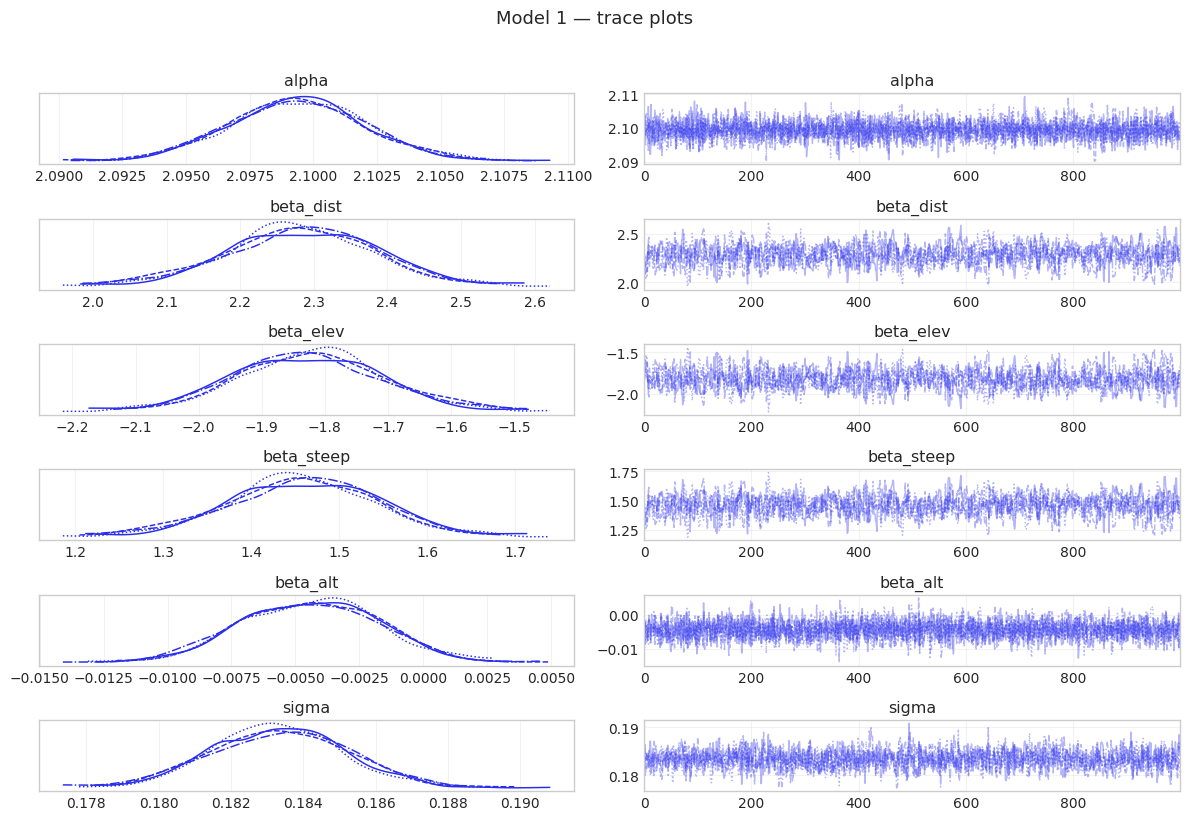

In [57]:
az.plot_trace(idata1, var_names=model1_vars, compact=True, figsize=(12, 8))
plt.suptitle("Model 1 — trace plots", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "model1_trace.png", bbox_inches="tight")
plt.show()


## 9. Posterior Analysis — Model 1

The posterior distributions below show the estimated effects on the log-time scale. Since the response is log-transformed, exponentiating a coefficient gives an approximate multiplicative effect on finish time for a one-standard-deviation increase in the corresponding predictor.

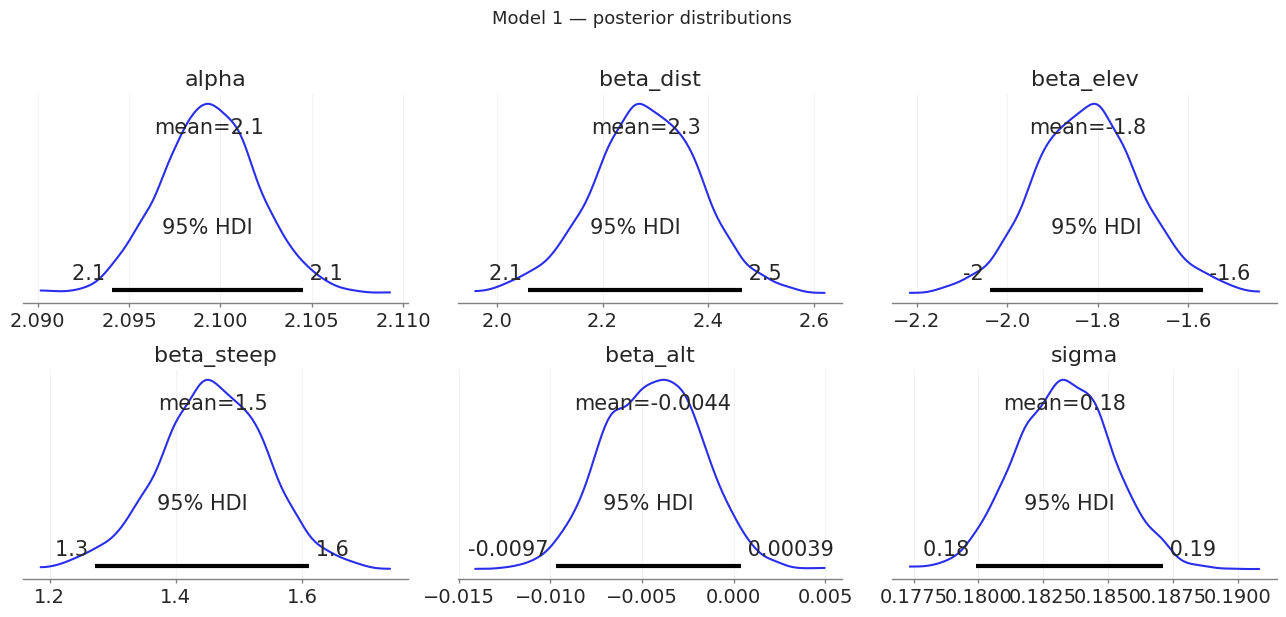

In [58]:
az.plot_posterior(idata1, var_names=model1_vars, hdi_prob=0.95, figsize=(13, 6))
plt.suptitle("Model 1 — posterior distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "model1_posterior_distributions.png", bbox_inches="tight")
plt.show()


In [59]:
def posterior_effect_table(idata: az.InferenceData, vars_: list[str]) -> pd.DataFrame:
    rows = []
    for var in vars_:
        samples = idata.posterior[var].values.reshape(-1)
        rows.append({
            "parameter": var,
            "posterior_mean": samples.mean(),
            "hdi_2.5%": np.percentile(samples, 2.5),
            "hdi_97.5%": np.percentile(samples, 97.5),
            "multiplicative_mean_exp(beta)": np.exp(samples.mean()) if var.startswith("beta") else np.nan,
            "P(parameter > 0)": np.mean(samples > 0),
        })
    return pd.DataFrame(rows)

model1_effects = posterior_effect_table(idata1, model1_vars)
display(model1_effects.round(4))

,parameter,posterior_mean,hdi_2.5%,hdi_97.5%,multiplicative_mean_exp(beta),P(parameter > 0)
0,alpha,2.0994,2.0942,2.1048,NaN,1.0000
1,beta_dist,2.2820,2.0726,2.4818,9.7964,1.0000
2,beta_elev,-1.8233,-2.0552,-1.5783,0.1615,0.0000
3,beta_steep,1.4582,1.2818,1.6251,4.2983,1.0000
4,beta_alt,-0.0044,-0.0095,0.0006,0.9956,0.0438
5,sigma,0.1833,0.1798,0.1870,NaN,1.0000


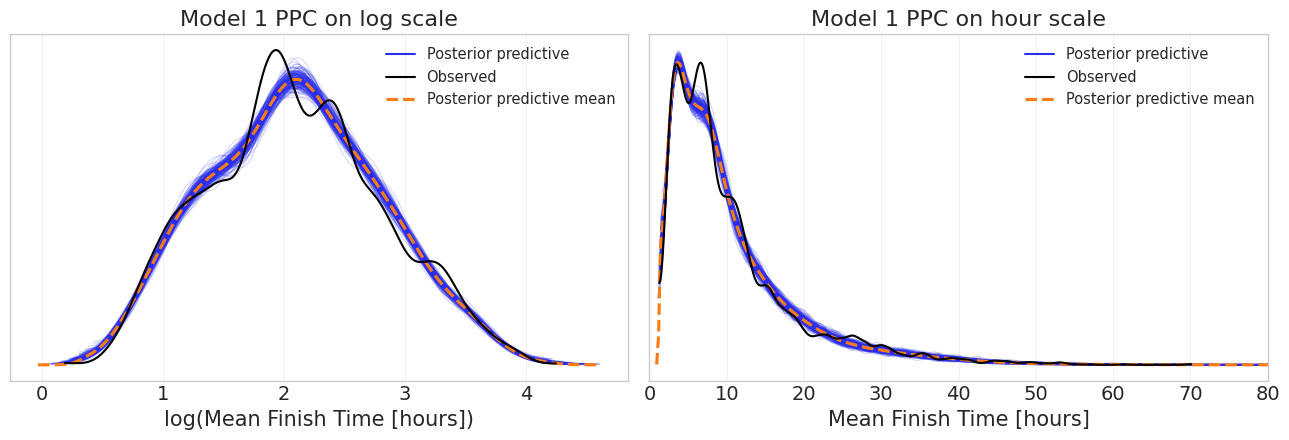

In [60]:
def make_hour_ppc_idata(y_obs: np.ndarray, time_rep: np.ndarray, label: str) -> az.InferenceData:
    return az.from_dict(
        observed_data={"finish_time": y_obs},
        posterior_predictive={"finish_time_rep": reshape_chain_draw(time_rep)},
        coords={"obs_id": np.arange(len(y_obs))},
        dims={"finish_time": ["obs_id"], "finish_time_rep": ["obs_id"]},
    )

idata1_hours = make_hour_ppc_idata(model_df["Mean Finish Time"].to_numpy(), time_rep1, "Model 1")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
az.plot_ppc(idata1, data_pairs={"log_time": "log_time_rep"}, num_pp_samples=POSTERIOR_PPC_DRAWS, ax=axes[0])
axes[0].set_title("Model 1 PPC on log scale")
axes[0].set_xlabel("log(Mean Finish Time [hours])")

az.plot_ppc(idata1_hours, data_pairs={"finish_time": "finish_time_rep"}, num_pp_samples=POSTERIOR_PPC_DRAWS, ax=axes[1])
axes[1].set_title("Model 1 PPC on hour scale")
axes[1].set_xlabel("Mean Finish Time [hours]")
axes[1].set_xlim(0, 80)

plt.tight_layout()
plt.savefig(FIG_DIR / "model1_ppc.png", bbox_inches="tight")
plt.show()

In [61]:
def posterior_stat_check(y_obs: np.ndarray, y_rep: np.ndarray, n_draws: int = 500) -> pd.DataFrame:
    y_rep = y_rep[:min(n_draws, len(y_rep))]
    checks = {
        "mean": (np.mean(y_obs), np.mean(y_rep, axis=1)),
        "std": (np.std(y_obs), np.std(y_rep, axis=1)),
        "min": (np.min(y_obs), np.min(y_rep, axis=1)),
        "max": (np.max(y_obs), np.max(y_rep, axis=1)),
        "skewness": (stats.skew(y_obs), np.array([stats.skew(row) for row in y_rep])),
        "excess_kurtosis": (stats.kurtosis(y_obs), np.array([stats.kurtosis(row) for row in y_rep])),
    }
    rows = []
    for name, (obs, sims) in checks.items():
        rows.append({
            "statistic": name,
            "observed": obs,
            "pp_median": np.median(sims),
            "pp_2.5%": np.percentile(sims, 2.5),
            "pp_97.5%": np.percentile(sims, 97.5),
            "inside_95%": np.percentile(sims, 2.5) <= obs <= np.percentile(sims, 97.5),
        })
    return pd.DataFrame(rows)

ppc_stats1 = posterior_stat_check(model_df["Mean Finish Time"].to_numpy(), time_rep1)
display(ppc_stats1.round(3))

,statistic,observed,pp_median,pp_2.5%,pp_97.5%,inside_95%
0,mean,10.579,10.543,10.451,10.637,True
1,std,8.512,8.378,8.197,8.580,True
2,min,1.205,1.288,1.057,1.465,True
3,max,70.132,75.621,63.531,98.825,True
4,skewness,1.954,2.021,1.895,2.184,True
5,excess_kurtosis,4.677,5.625,4.583,7.554,True


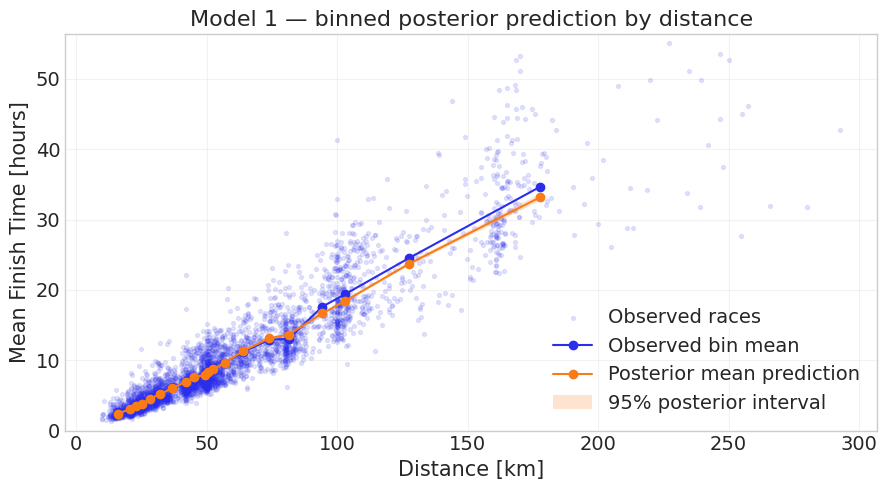

In [62]:
def plot_binned_predictions(data: pd.DataFrame, time_mu: np.ndarray, title: str, fname: str):
    pred_mean = time_mu.mean(axis=0)
    pred_lo = np.percentile(time_mu, 2.5, axis=0)
    pred_hi = np.percentile(time_mu, 97.5, axis=0)

    tmp = data[["Distance", "Mean Finish Time"]].copy()
    tmp["pred_mean"] = pred_mean
    tmp["pred_lo"] = pred_lo
    tmp["pred_hi"] = pred_hi
    tmp["bin"] = pd.qcut(tmp["Distance"], q=20, duplicates="drop")
    grouped = tmp.groupby("bin", observed=True).agg(
        distance_mid=("Distance", "mean"),
        observed_mean=("Mean Finish Time", "mean"),
        pred_mean=("pred_mean", "mean"),
        pred_lo=("pred_lo", "mean"),
        pred_hi=("pred_hi", "mean"),
    ).reset_index(drop=True)

    plot_df = sample_for_plot(data, n=4000)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(plot_df["Distance"], plot_df["Mean Finish Time"], s=8, alpha=0.12, label="Observed races")
    ax.plot(grouped["distance_mid"], grouped["observed_mean"], marker="o", linewidth=1.5, label="Observed bin mean")
    ax.plot(grouped["distance_mid"], grouped["pred_mean"], marker="o", linewidth=1.5, label="Posterior mean prediction")
    ax.fill_between(grouped["distance_mid"], grouped["pred_lo"], grouped["pred_hi"], alpha=0.20, label="95% posterior interval")
    ax.set_xlabel("Distance [km]")
    ax.set_ylabel("Mean Finish Time [hours]")
    ax.set_title(title)
    ax.set_ylim(0, min(80, data["Mean Finish Time"].quantile(0.995) * 1.2))
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, bbox_inches="tight")
    plt.show()

plot_binned_predictions(model_df, time_mu1, "Model 1 — binned posterior prediction by distance", "model1_binned_prediction.png")

## 10. Sampling Diagnostics — Model 2

Model 2 adds the Student-t degrees-of-freedom parameter `nu`. Its posterior is important because it tells us whether the data support heavy-tailed residuals.

In [63]:
model2_vars = ["alpha", "beta_dist", "beta_elev", "beta_steep", "beta_alt", "sigma", "nu"]
summary2 = diagnostics_table(idata2, model2_vars)
display(summary2)
print_sampler_health(idata2, "Model 2 — Student-t")

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
alpha,2.086,0.003,2.081,2.091,3542.900,2881.576,1.001
beta_dist,2.333,0.095,2.164,2.521,971.509,1382.705,1.004
beta_elev,-1.874,0.110,-2.092,-1.678,969.136,1413.255,1.004
beta_steep,1.497,0.080,1.352,1.653,970.464,1387.266,1.004
beta_alt,-0.002,0.003,-0.006,0.003,3666.549,2799.269,1.002
sigma,0.152,0.003,0.147,0.157,1634.665,2203.687,1.001
nu,6.223,0.537,5.293,7.253,1610.695,2081.392,1.003


Sampler health: Model 2 — Student-t
  Divergences: 0
  BFMI by chain: [0.98  1.142 0.991 1.061]


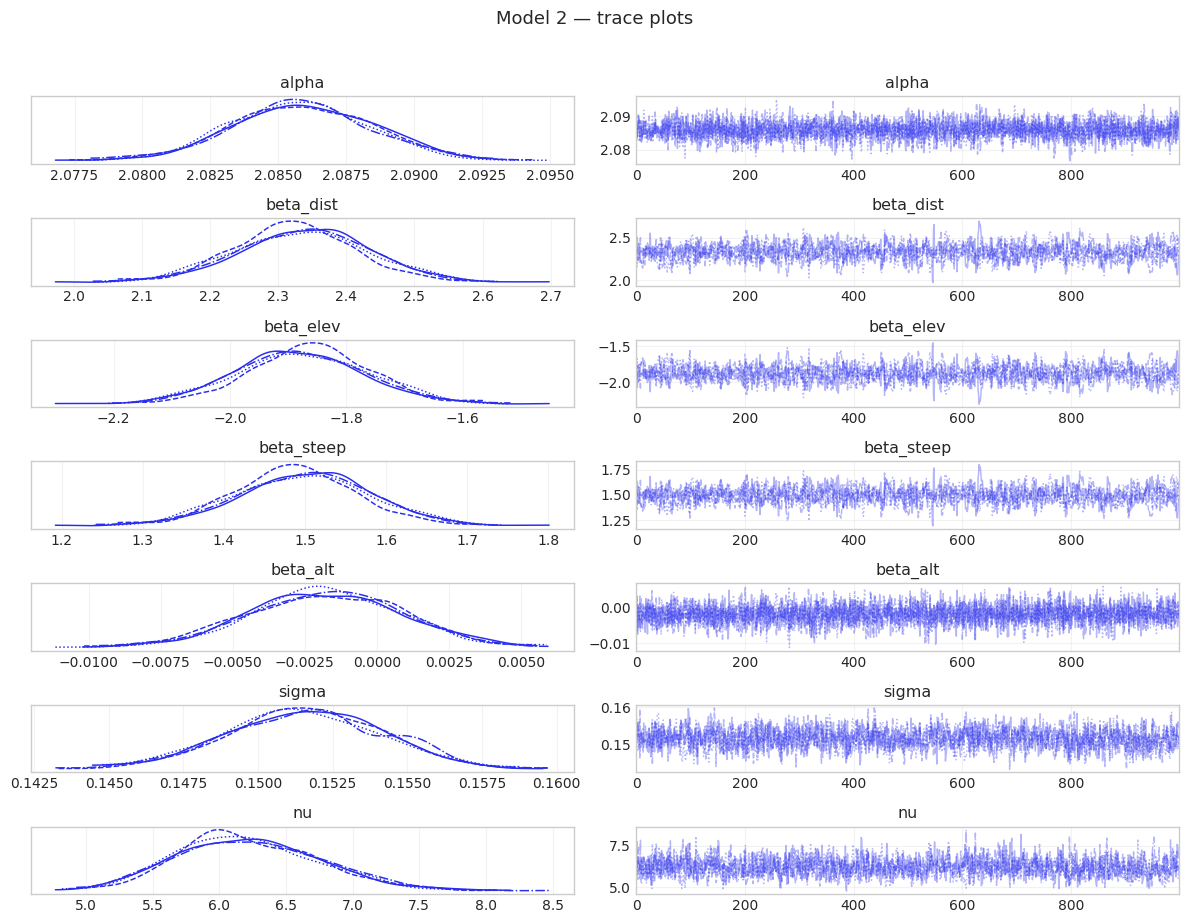

In [64]:
az.plot_trace(idata2, var_names=model2_vars, compact=True, figsize=(12, 9))
plt.suptitle("Model 2 — trace plots", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "model2_trace.png", bbox_inches="tight")
plt.show()


## 11. Posterior Analysis — Model 2

The Student-t model uses the same regression structure as Model 1, but replaces the Normal residual model with a heavy-tailed likelihood. The parameter `nu` controls how close the likelihood is to Normal: small values imply heavy tails; large values approximate Normal behavior.

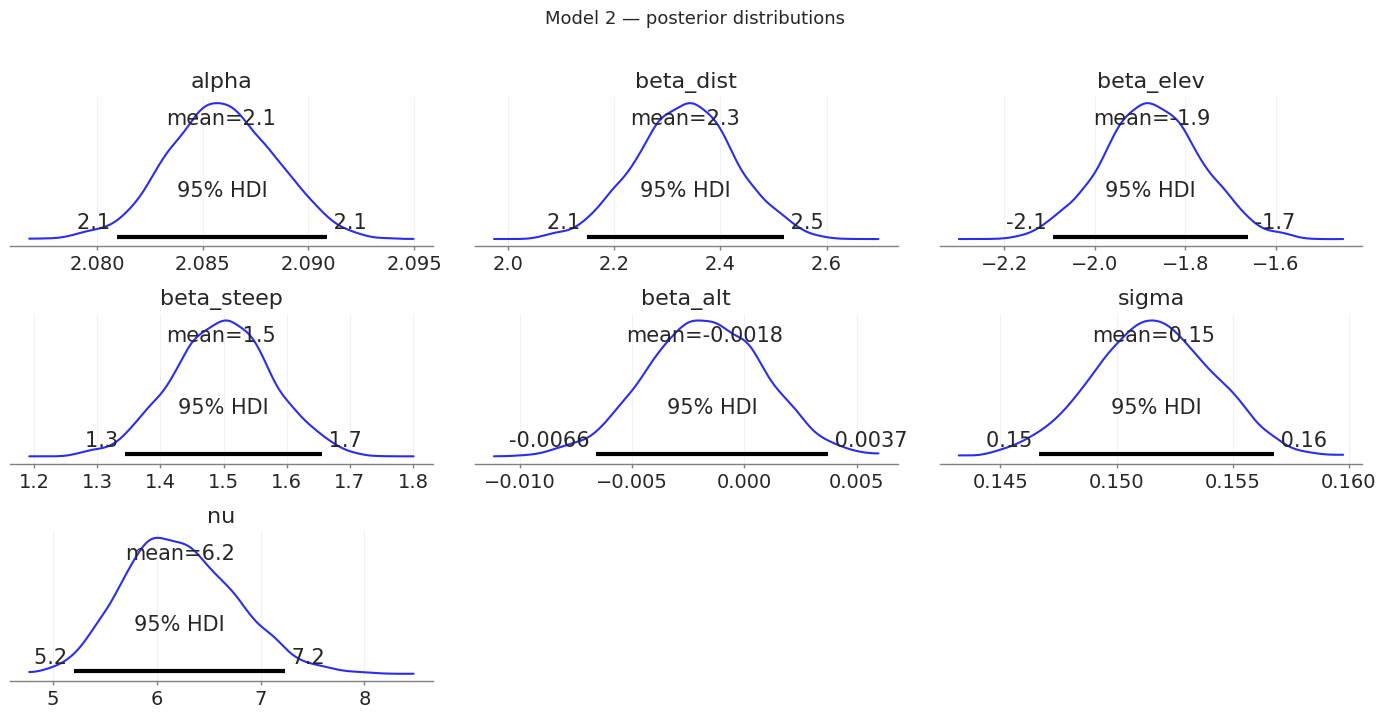

In [65]:
az.plot_posterior(idata2, var_names=model2_vars, hdi_prob=0.95, figsize=(14, 7))
plt.suptitle("Model 2 — posterior distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "model2_posterior_distributions.png", bbox_inches="tight")
plt.show()


In [66]:
model2_effects = posterior_effect_table(idata2, model2_vars)
display(model2_effects.round(4))

nu_samples = idata2.posterior["nu"].values.reshape(-1)
print(f"Posterior median nu: {np.median(nu_samples):.2f}")
print(f"P(nu < 10): {np.mean(nu_samples < 10):.3f}")
print(f"P(nu < 30): {np.mean(nu_samples < 30):.3f}")

,parameter,posterior_mean,hdi_2.5%,hdi_97.5%,multiplicative_mean_exp(beta),P(parameter > 0)
0,alpha,2.0859,2.0809,2.0908,NaN,1.0000
1,beta_dist,2.3331,2.1471,2.5193,10.3102,1.0000
2,beta_elev,-1.8742,-2.0885,-1.6583,0.1535,0.0000
3,beta_steep,1.4967,1.3398,1.6529,4.4671,1.0000
4,beta_alt,-0.0018,-0.0071,0.0033,0.9982,0.2555
5,sigma,0.1516,0.1464,0.1566,NaN,1.0000
6,nu,6.2233,5.2746,7.3309,NaN,1.0000


Posterior median nu: 6.19
P(nu < 10): 1.000
P(nu < 30): 1.000


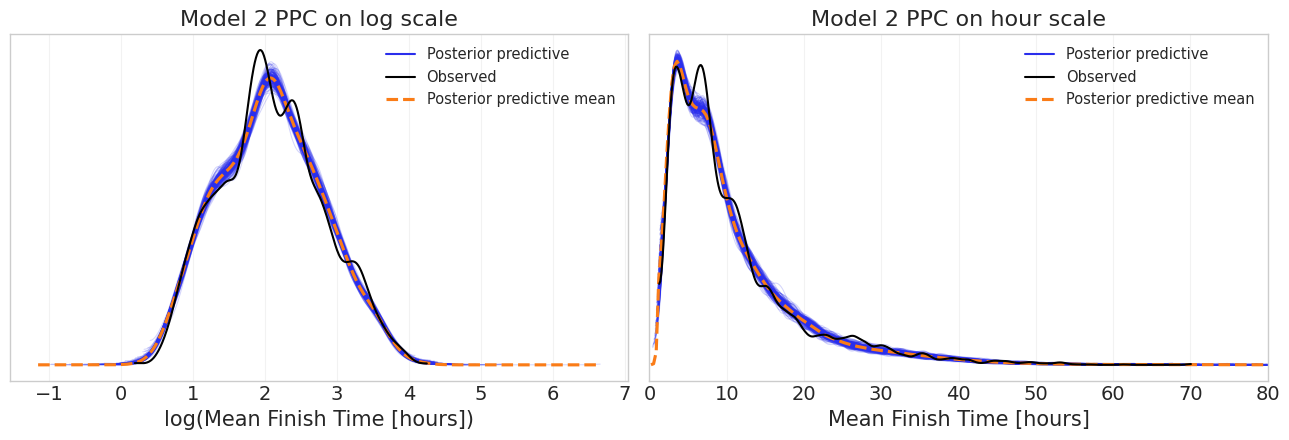

In [67]:
idata2_hours = make_hour_ppc_idata(model_df["Mean Finish Time"].to_numpy(), time_rep2, "Model 2")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
az.plot_ppc(idata2, data_pairs={"log_time": "log_time_rep"}, num_pp_samples=POSTERIOR_PPC_DRAWS, ax=axes[0])
axes[0].set_title("Model 2 PPC on log scale")
axes[0].set_xlabel("log(Mean Finish Time [hours])")

az.plot_ppc(idata2_hours, data_pairs={"finish_time": "finish_time_rep"}, num_pp_samples=POSTERIOR_PPC_DRAWS, ax=axes[1])
axes[1].set_title("Model 2 PPC on hour scale")
axes[1].set_xlabel("Mean Finish Time [hours]")
axes[1].set_xlim(0, 80)

plt.tight_layout()
plt.savefig(FIG_DIR / "model2_ppc.png", bbox_inches="tight")
plt.show()

,statistic,observed,pp_median,pp_2.5%,pp_97.5%,inside_95%
0,mean,10.579,10.452,10.365,10.557,False
1,std,8.512,8.415,8.236,8.698,True
2,min,1.205,1.084,0.501,1.397,True
3,max,70.132,78.201,63.876,131.761,True
4,skewness,1.954,2.064,1.910,2.542,True
5,excess_kurtosis,4.677,5.990,4.643,14.110,True


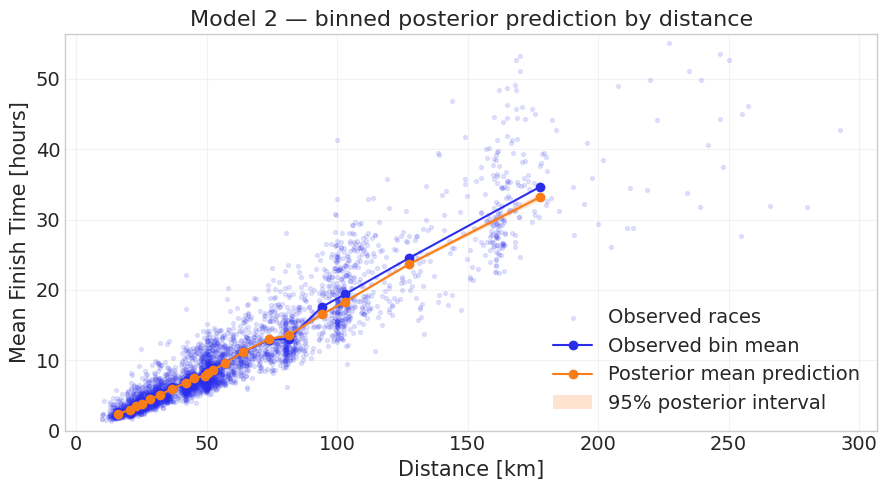

In [68]:
ppc_stats2 = posterior_stat_check(model_df["Mean Finish Time"].to_numpy(), time_rep2)
display(ppc_stats2.round(3))

plot_binned_predictions(model_df, time_mu2, "Model 2 — binned posterior prediction by distance", "model2_binned_prediction.png")

## 12. Model Comparison

Model comparison is based on pointwise log-likelihood values generated inside Stan. Both models use the same response, same observations, and same predictors, so WAIC and PSIS-LOO are directly comparable.

In [69]:
models = {
    "Model 1: Normal": idata1,
    "Model 2: Student-t": idata2,
}

loo1 = az.loo(idata1, pointwise=True)
loo2 = az.loo(idata2, pointwise=True)
waic1 = az.waic(idata1, pointwise=True)
waic2 = az.waic(idata2, pointwise=True)

loo_compare = az.compare(models, ic="loo")
waic_compare = az.compare(models, ic="waic")

print("PSIS-LOO comparison:")
display(loo_compare)
print("\nWAIC comparison:")
display(waic_compare)

PSIS-LOO comparison:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2: Student-t,0,1496.868786,6.844964,0.000000,0.943911,62.639311,0.000000,False,log
Model 1: Normal,1,1383.774214,6.922499,113.094571,0.056089,67.011154,21.470166,False,log



WAIC comparison:


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 2: Student-t,0,1496.877541,6.836209,0.00000,0.943918,62.639162,0.000000,False,log
Model 1: Normal,1,1383.783182,6.913531,113.09436,0.056082,67.010704,21.469808,False,log


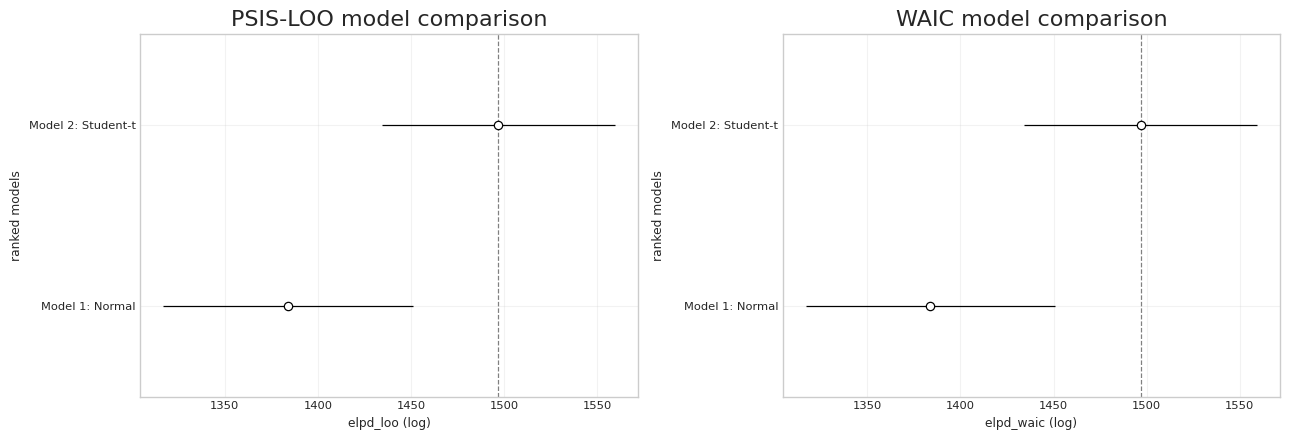

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
az.plot_compare(loo_compare, ax=axes[0])
axes[0].set_title("PSIS-LOO model comparison")
az.plot_compare(waic_compare, ax=axes[1])
axes[1].set_title("WAIC model comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_loo_waic.png", bbox_inches="tight")
plt.show()

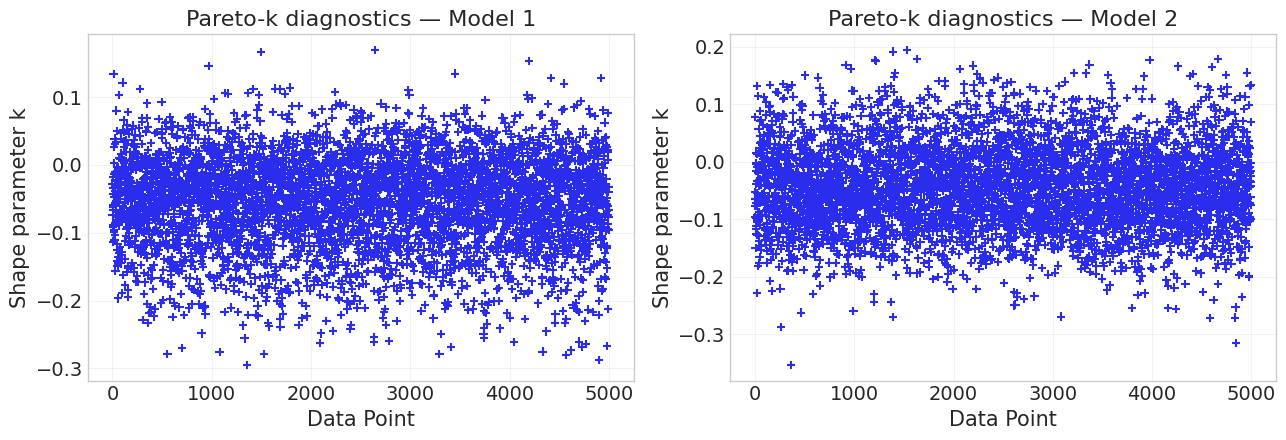

,model,max_pareto_k,n_k_gt_0.7,n_k_gt_1.0
0,Model 1: Normal,0.169,0,0
1,Model 2: Student-t,0.194,0,0


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
az.plot_khat(loo1, ax=axes[0])
axes[0].set_title("Pareto-k diagnostics — Model 1")
az.plot_khat(loo2, ax=axes[1])
axes[1].set_title("Pareto-k diagnostics — Model 2")
plt.tight_layout()
plt.savefig(FIG_DIR / "pareto_k_diagnostics.png", bbox_inches="tight")
plt.show()

pareto_summary = pd.DataFrame({
    "model": ["Model 1: Normal", "Model 2: Student-t"],
    "max_pareto_k": [float(np.max(loo1.pareto_k)), float(np.max(loo2.pareto_k))],
    "n_k_gt_0.7": [int(np.sum(loo1.pareto_k > 0.7)), int(np.sum(loo2.pareto_k > 0.7))],
    "n_k_gt_1.0": [int(np.sum(loo1.pareto_k > 1.0)), int(np.sum(loo2.pareto_k > 1.0))],
})
display(pareto_summary.round(3))

In [72]:
def compare_ppc_stats(stats1: pd.DataFrame, stats2: pd.DataFrame) -> pd.DataFrame:
    out = stats1[["statistic", "observed", "pp_median"]].rename(columns={"pp_median": "model1_pp_median"})
    out = out.merge(
        stats2[["statistic", "pp_median"]].rename(columns={"pp_median": "model2_pp_median"}),
        on="statistic",
    )
    out["abs_error_model1"] = (out["model1_pp_median"] - out["observed"]).abs()
    out["abs_error_model2"] = (out["model2_pp_median"] - out["observed"]).abs()
    out["better_by_statistic"] = np.where(out["abs_error_model2"] < out["abs_error_model1"], "Model 2", "Model 1")
    return out

ppc_compare_stats = compare_ppc_stats(ppc_stats1, ppc_stats2)
display(ppc_compare_stats.round(3))

,statistic,observed,model1_pp_median,model2_pp_median,abs_error_model1,abs_error_model2,better_by_statistic
0,mean,10.579,10.543,10.452,0.036,0.126,Model 1
1,std,8.512,8.378,8.415,0.134,0.097,Model 2
2,min,1.205,1.288,1.084,0.083,0.121,Model 1
3,max,70.132,75.621,78.201,5.488,8.069,Model 1
4,skewness,1.954,2.021,2.064,0.068,0.111,Model 1
5,excess_kurtosis,4.677,5.625,5.990,0.948,1.313,Model 1


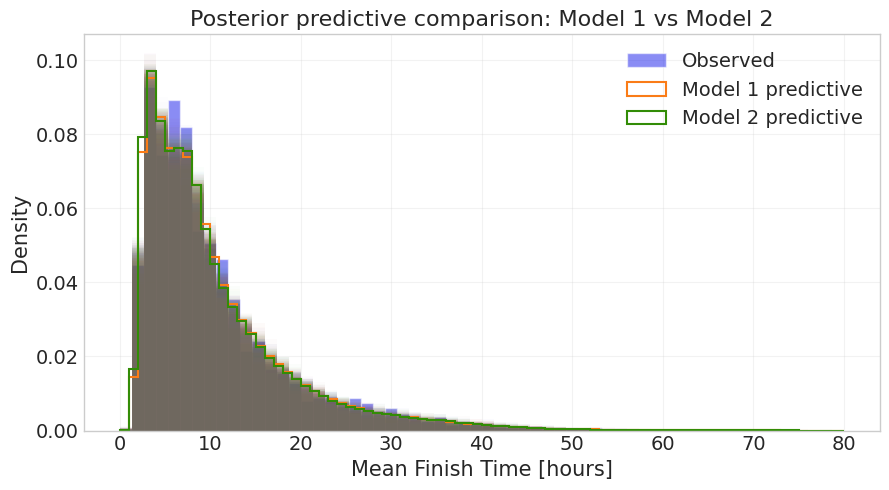

In [73]:
def plot_joint_ppc(y_obs: np.ndarray, time_rep_a: np.ndarray, time_rep_b: np.ndarray):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(y_obs, bins=60, density=True, alpha=0.55, edgecolor="white", label="Observed", range=(0, 80))

    for row in time_rep_a[:80]:
        ax.hist(row, bins=60, density=True, alpha=0.015, range=(0, 80))
    for row in time_rep_b[:80]:
        ax.hist(row, bins=60, density=True, alpha=0.015, range=(0, 80))

    ax.hist(time_rep_a[:200].reshape(-1), bins=80, density=True, histtype="step", linewidth=1.5, label="Model 1 predictive", range=(0, 80))
    ax.hist(time_rep_b[:200].reshape(-1), bins=80, density=True, histtype="step", linewidth=1.5, label="Model 2 predictive", range=(0, 80))
    ax.set_title("Posterior predictive comparison: Model 1 vs Model 2")
    ax.set_xlabel("Mean Finish Time [hours]")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "joint_ppc_model1_model2.png", bbox_inches="tight")
    plt.show()

plot_joint_ppc(model_df["Mean Finish Time"].to_numpy(), time_rep1, time_rep2)

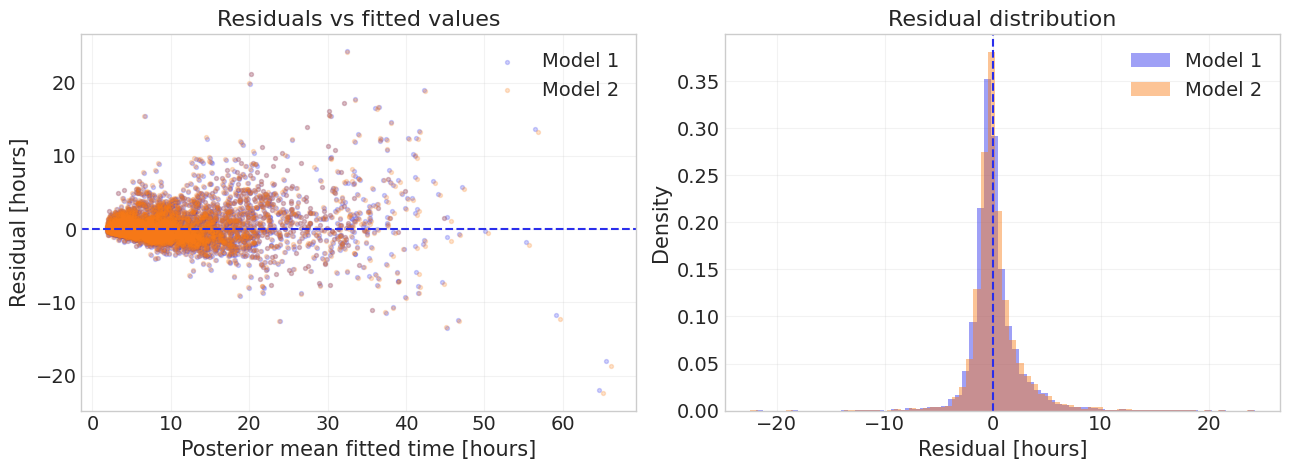

In [74]:
def plot_residual_comparison(data: pd.DataFrame, time_mu_a: np.ndarray, time_mu_b: np.ndarray):
    fitted_a = time_mu_a.mean(axis=0)
    fitted_b = time_mu_b.mean(axis=0)
    res_a = data["Mean Finish Time"].to_numpy() - fitted_a
    res_b = data["Mean Finish Time"].to_numpy() - fitted_b

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    axes[0].scatter(fitted_a, res_a, s=8, alpha=0.22, label="Model 1")
    axes[0].scatter(fitted_b, res_b, s=8, alpha=0.22, label="Model 2")
    axes[0].axhline(0, linestyle="--")
    axes[0].set_xlabel("Posterior mean fitted time [hours]")
    axes[0].set_ylabel("Residual [hours]")
    axes[0].set_title("Residuals vs fitted values")
    axes[0].legend()

    axes[1].hist(res_a, bins=70, density=True, alpha=0.45, label="Model 1")
    axes[1].hist(res_b, bins=70, density=True, alpha=0.45, label="Model 2")
    axes[1].axvline(0, linestyle="--")
    axes[1].set_xlabel("Residual [hours]")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Residual distribution")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "residual_comparison.png", bbox_inches="tight")
    plt.show()

plot_residual_comparison(model_df, time_mu1, time_mu2)

Selected model by PSIS-LOO: Model 2: Student-t


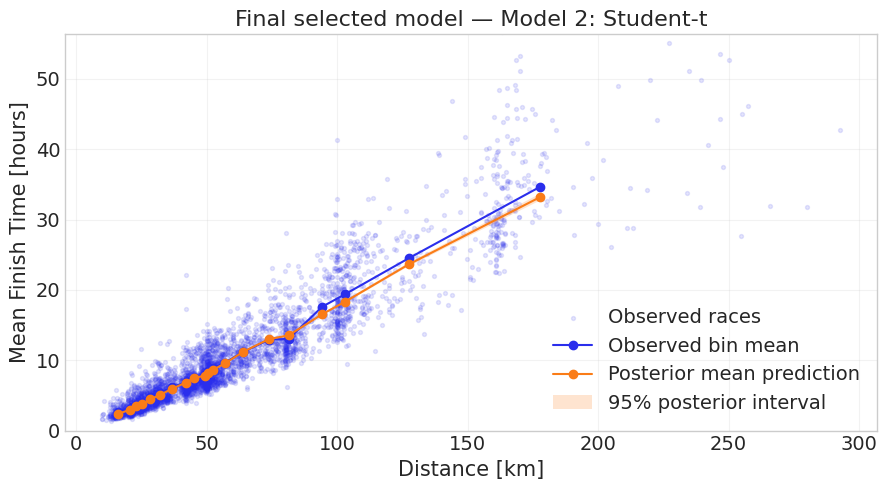

In [75]:
def select_winner(compare_df: pd.DataFrame) -> str:
    # az.compare sorts best model first by expected predictive accuracy.
    return str(compare_df.index[0])

winner = select_winner(loo_compare)
print(f"Selected model by PSIS-LOO: {winner}")

if winner == "Model 1: Normal":
    winner_time_mu = time_mu1
else:
    winner_time_mu = time_mu2

plot_binned_predictions(model_df, winner_time_mu, f"Final selected model — {winner}", "final_winner_prediction.png")

## 13. Conclusions

Use the computed diagnostics and comparison results above to write the final conclusions. The expected interpretation pattern is:

1. **Sampling quality:** Both models should be accepted only if R-hat values are close to 1, ESS is adequate, and there are no problematic divergences.
2. **Posterior interpretation:** Positive coefficients imply multiplicatively longer finish times for larger predictor values. Because predictors are standardized, coefficient magnitudes are comparable on a one-standard-deviation scale.
3. **Student-t robustness:** If the posterior for $\nu$ is small or moderate, the data support heavier-than-Normal residual tails. If $\nu$ is very large, Model 2 effectively collapses toward the Normal model.
4. **Model comparison:** The preferred model should be selected primarily by PSIS-LOO, with WAIC as a supporting criterion. Pareto-k diagnostics must be checked before trusting PSIS-LOO.
5. **Final model:** The final prediction plot should show whether the selected model captures the central trend and uncertainty across course distances.

### Limitations

- The model is linear on the log-time scale and may not fully capture nonlinear effects of terrain or interactions between distance and elevation.
- Weather, technical terrain, race organization, and participant-level ability are not included.
- The posterior fit uses a subsample for computational tractability; conclusions should be rechecked on a larger sample if computing resources allow.
- Altitude is approximated from the available `Elevation` column and may not fully represent the altitude profile of each course.

### Possible extensions

- Add race-category effects or hierarchical effects by race/country/year.
- Include interactions between distance and elevation gain.
- Use splines or Gaussian processes for nonlinear terrain effects.
- Model individual finish times instead of race-level mean finish times if runner-level data become available.

## 14. Checklist of Required Report Elements

This final notebook includes:

- EDA of the observed data,
- distribution of the response and key predictors,
- missing value summary,
- preprocessing visualization before/after transformations,
- scatterplots of response versus predictors,
- correlation matrix,
- model formulation and diagram,
- priors for all parameters,
- prior predictive checks,
- traceplots and rank plots for both models,
- R-hat / ESS / divergence diagnostics,
- posterior distributions and forest plots for both models,
- posterior predictive checks for both models,
- residual plots,
- WAIC comparison,
- PSIS-LOO comparison,
- Pareto-k diagnostics,
- final visualization of the selected model.